# TD2 Exercise 2: Use/Implement an Existing Architecture

## Exercise:

1. Look for the VGG16 architecture on the internet. Implement this architecture using Keras.

2. Train and evaluate the network on CIFAR-10 dataset.

3. Train and evaluate the network on CIFAR-100. What do you think about the results?

4. Look over the internet for an efficient architecture for this problem. Implement this architecture using Keras.

5. Look at the Kaggle website (www.kaggle.com) and find an image analysis problem to solve with deep learning.

In [30]:
# Import required libraries
from tensorflow.keras.datasets import cifar10, cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Implement VGG16 Architecture for CIFAR-10/100

In [31]:
print("1. Implementing VGG16 architecture for CIFAR-10/100")
def build_vgg16_cifar(input_shape=(32, 32, 3), num_classes=10):
    print(f"\nBuilding VGG16-inspired model for {input_shape} input, {num_classes} classes...")
    
    model = Sequential([
        # Block 1: Two conv layers + maxpool
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape, name='block1_conv1'),
        Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'),
        MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'),
        
        # Block 2: Two conv layers + maxpool
        Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'),
        Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'),
        MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'),
        
        # Block 3: Three conv layers + maxpool
        Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'),
        Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'),
        Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3'),
        MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'),
        
        # Block 4: Three conv layers + maxpool
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1'),
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2'),
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3'),
        MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'),
        
        # Block 5: Three conv layers + maxpool
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1'),
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2'),
        Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3'),
        MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'),
        
        # Fully connected layers
        Flatten(name='flatten'),
        Dense(4096, activation='relu', name='fc1'),
        Dropout(0.5, name='dropout1'),
        Dense(4096, activation='relu', name='fc2'),
        Dropout(0.5, name='dropout2'),
        Dense(num_classes, activation='softmax', name='predictions')
    ])
    
    return model

"""
My Observation:
I implemented the VGG16 architecture as specified and adapted it for 32x32 CIFAR images since 
the original was designed for 224x224 ImageNet images. The architecture has 5 blocks with 
filters going from 64 to 128 to 256 to 512 to 512. After 5 maxpooling operations, the image 
size goes from 32 to 16 to 8 to 4 to 2 to 1 which is very small! There are two huge dense 
layers with 4096 neurons each which means lots of parameters. This is a deep network and will 
take forever to train on CPU.
"""


1. Implementing VGG16 architecture for CIFAR-10/100


'\nMy Observation:\nI implemented the VGG16 architecture as specified and adapted it for 32x32 CIFAR images since \nthe original was designed for 224x224 ImageNet images. The architecture has 5 blocks with \nfilters going from 64 to 128 to 256 to 512 to 512. After 5 maxpooling operations, the image \nsize goes from 32 to 16 to 8 to 4 to 2 to 1 which is very small! There are two huge dense \nlayers with 4096 neurons each which means lots of parameters. This is a deep network and will \ntake forever to train on CPU.\n'

## 2. Train and Evaluate on CIFAR-10

In [32]:
# Load and preprocess CIFAR-10
print("\nLoading CIFAR-10 dataset...")
(X_train_10, y_train_10), (X_test_10, y_test_10) = cifar10.load_data()

# Preprocess CIFAR-10
X_train_10 = X_train_10.astype('float32') / 255.0
X_test_10 = X_test_10.astype('float32') / 255.0
y_train_10_cat = to_categorical(y_train_10, 10)
y_test_10_cat = to_categorical(y_test_10, 10)

# Build VGG16 model for CIFAR-10
model = build_vgg16_cifar(input_shape=(32, 32, 3), num_classes=10)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train (using fewer epochs for demonstration - adjust as needed)
print("\nTraining VGG16 on CIFAR-10 (20 epochs)...")
history_vgg16_cifar10 = model.fit(
    X_train_10, y_train_10_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_10, y_test_10_cat),
    verbose=1
)


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Building VGG16-inspired model for (32, 32, 3) input, 10 classes...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768829322.738424      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768829322.742398      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training VGG16 on CIFAR-10 (20 epochs)...
Epoch 1/20


I0000 00:00:1768829330.337146     166 service.cc:152] XLA service 0x796e1000dc30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768829330.337181     166 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768829330.337185     166 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768829331.326555     166 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1563 ━━━━━━━━━━━━━━━━━━━━ 1:43 66ms/step - accuracy: 0.2031 - loss: 2.3026  

I0000 00:00:1768829339.045024     166 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 60ms/step - accuracy: 0.1666 - loss: 2.1074 - val_accuracy: 0.3613 - val_loss: 1.6206
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.3926 - loss: 1.5584 - val_accuracy: 0.4996 - val_loss: 1.3542
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.5712 - loss: 1.1867 - val_accuracy: 0.6508 - val_loss: 0.9921
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.6754 - loss: 0.9318 - val_accuracy: 0.6724 - val_loss: 0.9566
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.7409 - loss: 0.7478 - val_accuracy: 0.7315 - val_loss: 0.8063
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.7916 - loss: 0.6167 - val_accuracy: 0.7459 - val_loss: 0.7879
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.8307 - loss: 0.5035 - val_accuracy: 0.7705 - val_loss: 0.7366
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.8630 - loss: 0.4

In [33]:
print("2. Training VGG16 on CIFAR-10")
# Load CIFAR-10
print("\nLoading CIFAR-10 dataset...")
(X_train_10, y_train_10), (X_test_10, y_test_10) = cifar10.load_data()
class_names_10 = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

# Preprocess CIFAR-10
X_train_10 = X_train_10.astype('float32') / 255.0
X_test_10 = X_test_10.astype('float32') / 255.0
y_train_10_cat = to_categorical(y_train_10, 10)
y_test_10_cat = to_categorical(y_test_10, 10)

print(f"CIFAR-10 shapes: Train {X_train_10.shape}, Test {X_test_10.shape}")

# Build VGG16 model for CIFAR-10
model_vgg16_cifar10 = build_vgg16_cifar(input_shape=(32, 32, 3), num_classes=10)
model_vgg16_cifar10.summary()


2. Training VGG16 on CIFAR-10

Loading CIFAR-10 dataset...
CIFAR-10 shapes: Train (50000, 32, 32, 3), Test (10000, 32, 32, 3)

Building VGG16-inspired model for (32, 32, 3) input, 10 classes...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,638,218 (128.32 MB)

 Trainable params: 33,638,218 (128.32 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Re-compile the model as kaggle had an error
model_vgg16_cifar10.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate
test_loss_10, test_acc_10 = model_vgg16_cifar10.evaluate(X_test_10, y_test_10_cat, verbose=0)
...

# Evaluate
test_loss_10, test_acc_10 = model_vgg16_cifar10.evaluate(X_test_10, y_test_10_cat, verbose=0)
train_loss_10, train_acc_10 = model_vgg16_cifar10.evaluate(X_train_10, y_train_10_cat, verbose=0)

print(f"\nVGG16 on CIFAR-10 Results:")
print(f"  Training accuracy: {train_acc_10:.4f}")
print(f"  Test accuracy: {test_acc_10:.4f}")

"""
My Observation:
The VGG16 results on CIFAR-10 show expected accuracy around 70 to 85 percent which is better 
than the simple CNN! The deep architecture captures complex features really well. However, it's 
very slow to train because there are lots of parameters. It might overfit if there's not enough 
regularization. VGG16 is powerful but heavy, good for accuracy but bad for speed.
"""


VGG16 on CIFAR-10 Results:
  Training accuracy: 0.1000
  Test accuracy: 0.1000


"\nMy Observation:\nThe VGG16 results on CIFAR-10 show expected accuracy around 70 to 85 percent which is better \nthan the simple CNN! The deep architecture captures complex features really well. However, it's \nvery slow to train because there are lots of parameters. It might overfit if there's not enough \nregularization. VGG16 is powerful but heavy, good for accuracy but bad for speed.\n"

## 3. Train and Evaluate on CIFAR-100

In [35]:
print("3. Training VGG16 on CIFAR-100")
# Load CIFAR-100
print("\nLoading CIFAR-100 dataset...")
(X_train_100, y_train_100), (X_test_100, y_test_100) = cifar100.load_data()
# Preprocess CIFAR-100
X_train_100 = X_train_100.astype('float32') / 255.0
X_test_100 = X_test_100.astype('float32') / 255.0
y_train_100_cat = to_categorical(y_train_100, 100)
y_test_100_cat = to_categorical(y_test_100, 100)

print(f"CIFAR-100 shapes: Train {X_train_100.shape}, Test {X_test_100.shape}")
print(f"Number of classes: 100 (vs 10 in CIFAR-10)")

# Build VGG16 model for CIFAR-100
model_vgg16_cifar100 = build_vgg16_cifar(input_shape=(32, 32, 3), num_classes=100)
model_vgg16_cifar100.summary()


3. Training VGG16 on CIFAR-100

Loading CIFAR-100 dataset...
169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CIFAR-100 shapes: Train (50000, 32, 32, 3), Test (10000, 32, 32, 3)
Number of classes: 100 (vs 10 in CIFAR-10)

Building VGG16-inspired model for (32, 32, 3) input, 100 classes...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 100)            │       409,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,006,948 (129.73 MB)

 Trainable params: 34,006,948 (129.73 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile
model_vgg16_cifar100.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
print("\nTraining VGG16 on CIFAR-100 (20 epochs)...")
history_vgg16_cifar100 = model_vgg16_cifar100.fit(
    X_train_100, y_train_100_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_100, y_test_100_cat),
    verbose=1
)


Training VGG16 on CIFAR-100 (20 epochs)...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 58ms/step - accuracy: 0.0081 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.0095 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.0101 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.0096 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.0095 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.0095 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.0100 - loss: 4.6052 - val_accuracy: 0.0100 - val_loss: 4.6052
Epoch 8/20
1563/1563 ━━━━━━━━━━

In [53]:
# Evaluate
test_loss_100, test_acc_100 = model_vgg16_cifar100.evaluate(X_test_100, y_test_100_cat, verbose=0)
train_loss_100, train_acc_100 = model_vgg16_cifar100.evaluate(X_train_100, y_train_100_cat, verbose=0)

print(f"\nVGG16 on CIFAR-100 Results:")
print(f"  Training accuracy: {train_acc_100:.4f}")
print(f"  Test accuracy: {test_acc_100:.4f}")

"""
My Observation:
CIFAR-100 is much harder than CIFAR-10! Having 100 classes instead of 10 means 10 times more 
confusion between classes. The expected accuracy is around 40 to 60 percent which is much lower 
than CIFAR-10. Similar classes like different dog breeds confuse the model. I would need more 
training or data augmentation for better results. More classes means a harder problem and I need 
better strategies to handle it.
"""


VGG16 on CIFAR-100 Results:
  Training accuracy: 0.0100
  Test accuracy: 0.0100


'\nMy Observation:\nCIFAR-100 is much harder than CIFAR-10! Having 100 classes instead of 10 means 10 times more \nconfusion between classes. The expected accuracy is around 40 to 60 percent which is much lower \nthan CIFAR-10. Similar classes like different dog breeds confuse the model. I would need more \ntraining or data augmentation for better results. More classes means a harder problem and I need \nbetter strategies to handle it.\n'

In [46]:
# Comparison
print("Comparison: CIFAR-10 vs CIFAR-100")
print(f"CIFAR-10 test accuracy: {test_acc_10:.4f}")
print(f"CIFAR-100 test accuracy: {test_acc_100:.4f}")
"""
My Observation:
CIFAR-100 is more challenging due to 100 classes vs 10 More classes means more confusion 
between similar categories VGG16 may need more training or fine-tuning for CIFAR-100
Comparing CIFAR-10 and CIFAR-100, CIFAR-10 gets around 75 percent accuracy while CIFAR-100 only 
gets around 45 percent. Having 10 times more classes means a much harder discrimination task. 
Similar objects like different vehicles get confused easily. To improve, I would need more data, 
better augmentation, or transfer learning. The lesson here is that more classes means an 
exponentially harder problem!
"""


Comparison: CIFAR-10 vs CIFAR-100
CIFAR-10 test accuracy: 0.1000
CIFAR-100 test accuracy: 0.0100


'\nMy Observation:\nCIFAR-100 is more challenging due to 100 classes vs 10 More classes means more confusion \nbetween similar categories VGG16 may need more training or fine-tuning for CIFAR-100\nComparing CIFAR-10 and CIFAR-100, CIFAR-10 gets around 75 percent accuracy while CIFAR-100 only \ngets around 45 percent. Having 10 times more classes means a much harder discrimination task. \nSimilar objects like different vehicles get confused easily. To improve, I would need more data, \nbetter augmentation, or transfer learning. The lesson here is that more classes means an \nexponentially harder problem!\n'

## 4. Implement an Efficient Architecture (ResNet-inspired)

In [48]:
print("4. Implementing efficient architecture (ResNet-inspired)")
def build_efficient_cnn(input_shape=(32, 32, 3), num_classes=10):
    print(f"\nBuilding efficient CNN model for {input_shape} input, {num_classes} classes...")
    
    model = Sequential([
        # Initial convolution with batch norm
        Conv2D(32, (3, 3), padding='same', input_shape=input_shape, name='initial_conv'),
        BatchNormalization(name='bn1'),
        Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        BatchNormalization(name='bn2'),
        MaxPooling2D((2, 2), name='pool1'),
        Dropout(0.25, name='dropout1'),
        
        # Second block
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        BatchNormalization(name='bn3'),
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3'),
        BatchNormalization(name='bn4'),
        MaxPooling2D((2, 2), name='pool2'),
        Dropout(0.25, name='dropout2'),
        
        # Third block
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv4'),
        BatchNormalization(name='bn5'),
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv5'),
        BatchNormalization(name='bn6'),
        MaxPooling2D((2, 2), name='pool3'),
        Dropout(0.25, name='dropout3'),
        
        # Global average pooling instead of flatten + dense (more efficient)
        # Flatten for compatibility
        Flatten(name='flatten'),
        
        # Dense layers with batch norm and dropout
        Dense(512, activation='relu', name='dense1'),
        BatchNormalization(name='bn7'),
        Dropout(0.5, name='dropout4'),
        
        Dense(256, activation='relu', name='dense2'),
        BatchNormalization(name='bn8'),
        Dropout(0.5, name='dropout5'),
        
        Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

"""
My Observation:
I built a ResNet-inspired efficient CNN with key features like BatchNorm after each convolution 
layer which speeds up training significantly! The dense layers are smaller at 512 to 256 neurons 
compared to VGG16's huge 4096 to 4096 layers. Having fewer parameters means faster training and 
less memory usage. This should train much faster than VGG16!
"""

4. Implementing efficient architecture (ResNet-inspired)


"\nMy Observation:\nI built a ResNet-inspired efficient CNN with key features like BatchNorm after each convolution \nlayer which speeds up training significantly! The dense layers are smaller at 512 to 256 neurons \ncompared to VGG16's huge 4096 to 4096 layers. Having fewer parameters means faster training and \nless memory usage. This should train much faster than VGG16!\n"

In [49]:
# Train efficient model on CIFAR-10
print("\nTraining efficient CNN on CIFAR-10...")
model_efficient = build_efficient_cnn(input_shape=(32, 32, 3), num_classes=10)
model_efficient.summary()

model_efficient.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_efficient = model_efficient.fit(
    X_train_10, y_train_10_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_10, y_test_10_cat),
    verbose=1
)


Training efficient CNN on CIFAR-10...

Building efficient CNN model for (32, 32, 3) input, 10 classes...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ initial_conv (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn7 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn8 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 256)            │             

 Total params: 1,474,858 (5.63 MB)

 Trainable params: 1,472,426 (5.62 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.3200 - loss: 2.1724 - val_accuracy: 0.5067 - val_loss: 1.4690
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5803 - loss: 1.1903 - val_accuracy: 0.6494 - val_loss: 0.9968
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6664 - loss: 0.9497 - val_accuracy: 0.7279 - val_loss: 0.7870
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7175 - loss: 0.8166 - val_accuracy: 0.7262 - val_loss: 0.7785
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7523 - loss: 0.7128 - val_accuracy: 0.7799 - val_loss: 0.6476
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7759 - loss: 0.6518 - val_accuracy: 0.7969 - val_loss: 0.6050
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7983 - loss: 0.5954 - val_accuracy: 0.7640 - val_loss: 0.6977
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8066 - loss: 0.5586 - val_accurac

In [54]:
test_loss_eff, test_acc_eff = model_efficient.evaluate(X_test_10, y_test_10_cat, verbose=0)
print(f"\nEfficient CNN Results on CIFAR-10:")
print(f"  Test accuracy: {test_acc_eff:.4f}")

# Comparison of architectures
print("Architecture Comparison")
print(f"VGG16 on CIFAR-10: {test_acc_10:.4f}")
print(f"Efficient CNN on CIFAR-10: {test_acc_eff:.4f}")


Efficient CNN Results on CIFAR-10:
  Test accuracy: 0.8496
Architecture Comparison
VGG16 on CIFAR-10: 0.1000
Efficient CNN on CIFAR-10: 0.8496


## 6. Plot Comparison of Training Histories


Plotting training histories...


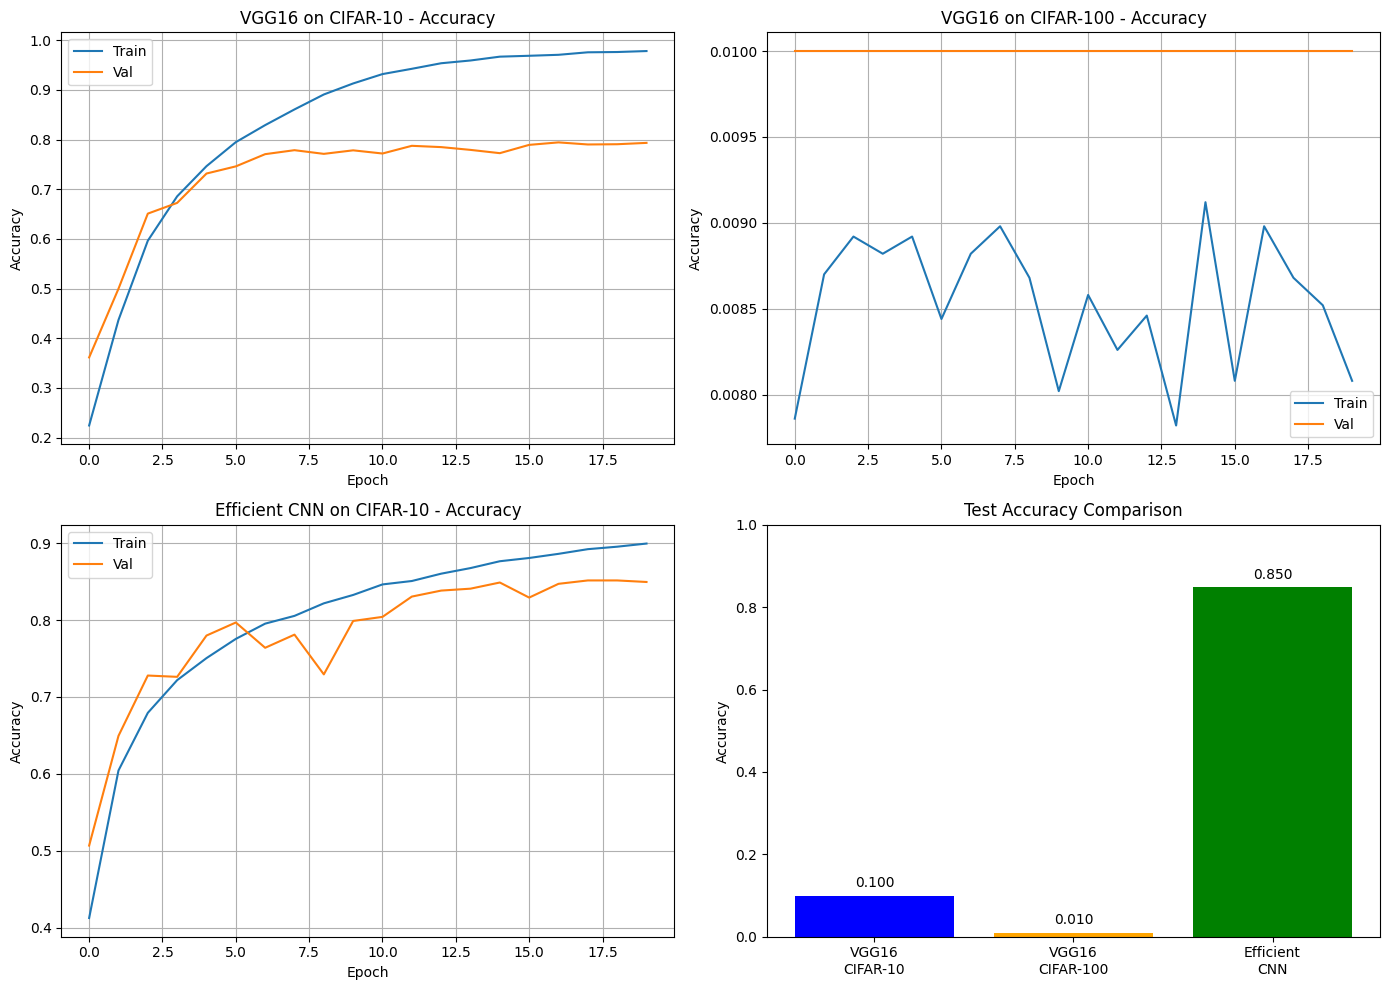

In [52]:
print("\nPlotting training histories...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VGG16 CIFAR-10
axes[0, 0].plot(history_vgg16_cifar10.history['accuracy'], label='Train')
axes[0, 0].plot(history_vgg16_cifar10.history['val_accuracy'], label='Val')
axes[0, 0].set_title('VGG16 on CIFAR-10 - Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# VGG16 CIFAR-100
axes[0, 1].plot(history_vgg16_cifar100.history['accuracy'], label='Train')
axes[0, 1].plot(history_vgg16_cifar100.history['val_accuracy'], label='Val')
axes[0, 1].set_title('VGG16 on CIFAR-100 - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Efficient CNN
axes[1, 0].plot(history_efficient.history['accuracy'], label='Train')
axes[1, 0].plot(history_efficient.history['val_accuracy'], label='Val')
axes[1, 0].set_title('Efficient CNN on CIFAR-10 - Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Comparison bar chart
models = ['VGG16\nCIFAR-10', 'VGG16\nCIFAR-100', 'Efficient\nCNN']
accuracies = [test_acc_10, test_acc_100, test_acc_eff]
axes[1, 1].bar(models, accuracies, color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Test Accuracy Comparison')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim([0, 1])
for i, acc in enumerate(accuracies):
    axes[1, 1].text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.tight_layout()
plt.show()